In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS, summarize)

from sklearn.discriminant_analysis import (QuadraticDiscriminantAnalysis as QDA,
                                           LinearDiscriminantAnalysis as LDA)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

13) This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1,089
weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?

In [139]:
Weekly = pd.read_csv('..\..\Datasets\Weekly.csv')
Weekly.info()
#Adicionar provavelmente temporariamente para apenas medir a correlação
Weekly['Subiu'] = Weekly['Direction'].map({'Up':1,'Down': 0})
Weekly['Direction'] = Weekly['Direction'].astype('category')
Weekly['Direction'].value_counts()
Weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float6

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\olive\AppData\Local\Temp\ipykernel_5168\931924802.py:1: SyntaxWarning: invalid escape sequence '\.'
  Weekly = pd.read_csv('..\..\Datasets\Weekly.csv')


In [140]:
Weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Subiu
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460,-0.022200
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032,-0.050004
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167,0.072696
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244,-0.022913
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826,-0.020549
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013,-0.018168
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078,-0.017995
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000,0.720025
Subiu,-0.022200,-0.050004,0.072696,-0.022913,-0.020549,-0.018168,-0.017995,0.720025,1.000000


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Lag1'}>,
        <Axes: title={'center': 'Lag2'}>],
       [<Axes: title={'center': 'Lag3'}>,
        <Axes: title={'center': 'Lag4'}>,
        <Axes: title={'center': 'Lag5'}>],
       [<Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'Today'}>, <Axes: >]], dtype=object)

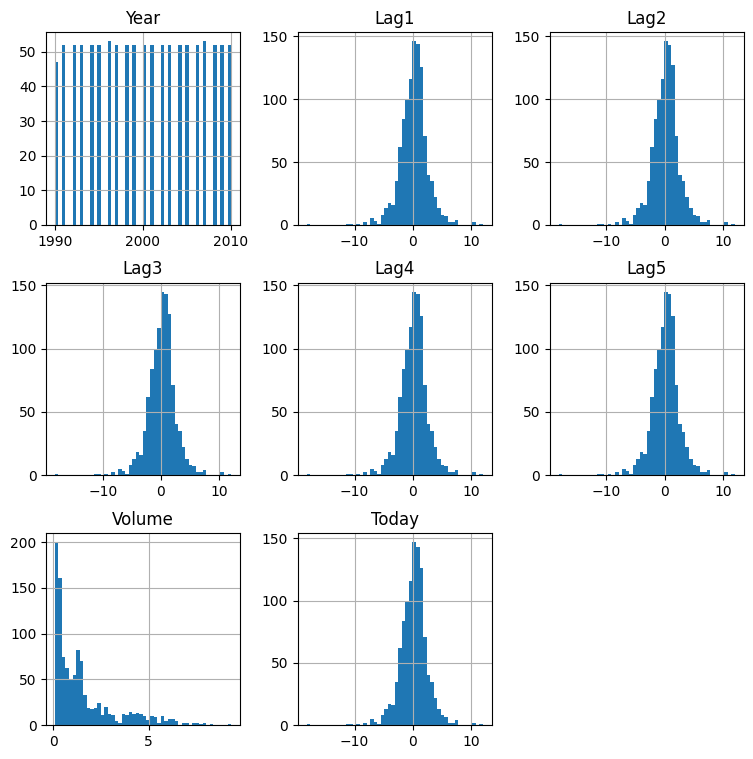

In [141]:
Weekly.drop(columns=['Subiu'],inplace=True)
Weekly.hist(figsize=(9,9), bins=50)

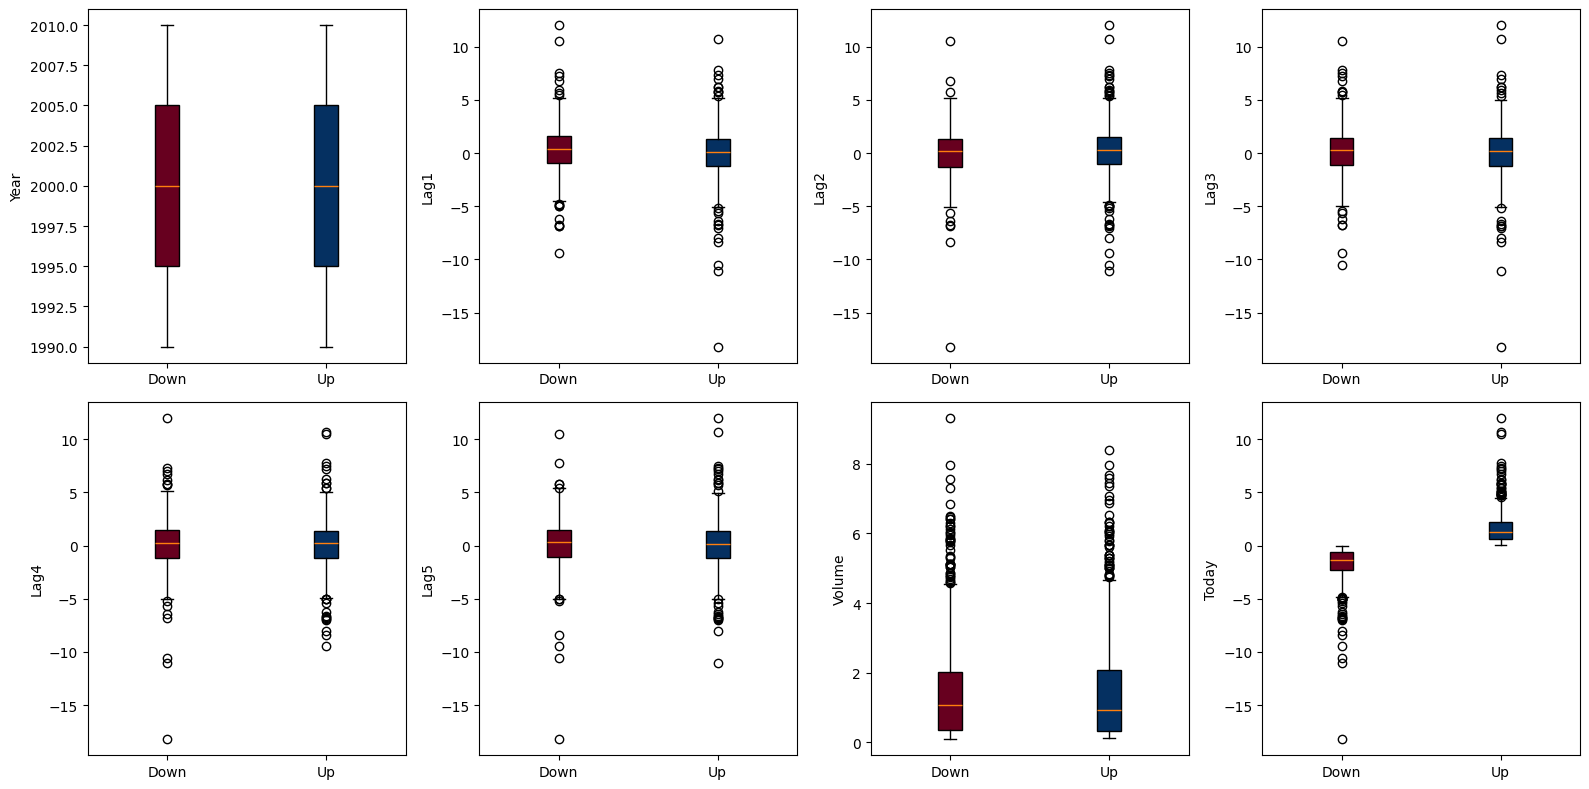

In [142]:
def plotar_boxplot(df, nome_coluna_categorica, figsize, ncolunas=4, cmap_nome='RdBu'):
    colunas = df.select_dtypes(include=[np.number]).columns
    nlinhas = len(colunas)//ncolunas
    if (len(colunas)%ncolunas) > 0:
        nlinhas += 1
    categorias = df[nome_coluna_categorica].unique()
    ncategorias = len(categorias)
    cmap = plt.get_cmap(cmap_nome)
    cores = [cmap(i / max(1, ncategorias - 1)) for i in range(ncategorias)]

    fig, axes = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=figsize)
    axes_flat = axes.flatten()
    for coluna, ax in zip(colunas, axes_flat):
        ax.set_ylabel(coluna)
        box = ax.boxplot([df[df[nome_coluna_categorica] == cat][coluna] for cat in categorias], 
                        tick_labels=categorias, 
                        patch_artist=True);
        
        for caixa, cor in zip(box['boxes'], cores):
            caixa.set_facecolor(cor)
    plt.tight_layout()
    plt.show()

plotar_boxplot(Weekly, 'Direction', (16,8))

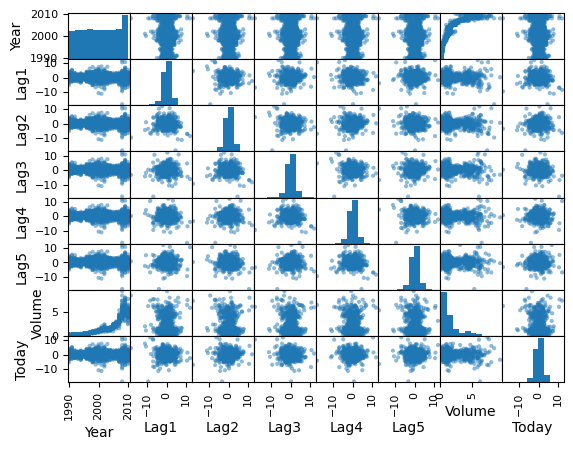

In [143]:
pd.plotting.scatter_matrix(Weekly);

(b) Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume
as predictors. Use the summary function to print the results. Do
any of the predictors appear to be statistically significant? If so,
which ones?

In [144]:
Direction = Weekly.Direction
scaler = StandardScaler()
nomes_preditores = Weekly.columns.drop(['Direction','Today','Year'])
preditores = MS(nomes_preditores).fit_transform(Weekly)
preditores_std = scaler.fit_transform(preditores)
preditores_std = pd.DataFrame(preditores_std, index=preditores.index, columns=preditores.columns)

In [145]:
glm = sm.GLM(Direction=='Up', preditores,family=sm.families.Binomial())
resultados = glm.fit()
summarize(resultados)


,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


In [146]:
labels = np.array(['Down']*len(resultados.fittedvalues))
labels[resultados.fittedvalues>0.5] = 'Up'
confusion_table(labels, Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [147]:
glm_std = sm.GLM(Direction=='Up', preditores_std,family=sm.families.Binomial())
resultados_std = glm_std.fit()
summarize(resultados_std)

,coef,std err,z,P>|z|
intercept,0.0000,0.000,NaN,NaN
Lag1,-0.0965,0.062,-1.557,0.119
Lag2,0.1361,0.063,2.160,0.031
Lag3,-0.0359,0.062,-0.575,0.565
Lag4,-0.0638,0.062,-1.029,0.304
Lag5,-0.0333,0.062,-0.539,0.590
Volume,-0.0390,0.062,-0.629,0.529


In [148]:
labels_std = np.array(['Down']*len(resultados_std.fittedvalues))
labels_std[resultados.fittedvalues>0.5] = 'Up'
confusion_table(labels_std, Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


Lag2 é o único preditor que tem correlação significante.

(d) Nowfitthe logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 and 2010).

In [149]:
treino = (Weekly.Year <= 2008)
X = MS(['Lag2']).fit_transform(Weekly)
X_treino, X_teste = X.loc[treino], X.loc[~treino]
y_treino, y_teste = Weekly[treino]['Direction'], Weekly[~treino]['Direction']

In [150]:
glm = sm.GLM(y_treino=='Up', X_treino, family=sm.families.Binomial())
resultados = glm.fit()
predicao_teste = resultados.predict(X_teste)
label_teste = np.array(['Down']*len(predicao_teste))
label_teste[predicao_teste > 0.5] = 'Up'
print(summarize(resultados))
confusion_LR = confusion_table(label_teste, y_teste)
confusion_LR

             coef  std err      z  P>|z|
intercept  0.2033    0.064  3.162  0.002
Lag2       0.0581    0.029  2.024  0.043


Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [151]:
def metricas_matriz_confusao(matriz_confusao):
    TP = matriz_confusao['Up']['Up']
    TN = matriz_confusao['Down']['Down'] 
    FP = matriz_confusao['Up']['Down'] 
    FN = matriz_confusao['Down']['Up']
    TP,TN,FP,FN
    acuracia = (TP+TN) / (TP+TN+FP+FN)
    precisao = TP/(TP+FP)
    sensibilidade = TP/(TP+FN)
    especificidade = TN/(TN+FP)
    print(f'Acurácia: {acuracia}\nPrecisão: {precisao}\nSensibilidade: {sensibilidade}\nEspecificidade: {especificidade}')
    return acuracia, precisao, sensibilidade, especificidade
metricas_matriz_confusao(confusion_LR)

Acurácia: 0.625
Precisão: 0.9180327868852459
Sensibilidade: 0.6222222222222222
Especificidade: 0.6428571428571429


(np.float64(0.625),
 np.float64(0.9180327868852459),
 np.float64(0.6222222222222222),
 np.float64(0.6428571428571429))

(e) Repeat (d) using LDA.

In [152]:
lda = LDA(store_covariance=True)
X_treino, X_teste = [pred.drop(columns=['intercept']) for pred in [X_treino, X_teste]]
lda.fit(X_treino, y_treino)
predicao_LDA = lda.predict(X_teste)
confusion_LDA = confusion_table(predicao_LDA, y_teste)
metricas_matriz_confusao(confusion_LDA)
confusion_LDA

Acurácia: 0.625
Precisão: 0.9180327868852459
Sensibilidade: 0.6222222222222222
Especificidade: 0.6428571428571429


Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


(f) Repeat (d) using QDA.

In [153]:
qda = QDA(store_covariance=True)
qda.fit(X_treino, y_treino)
predicao_QDA = qda.predict(X_teste)
confusion_QDA = confusion_table(predicao_QDA, y_teste)
metricas_matriz_confusao(confusion_QDA)
confusion_QDA

Acurácia: 0.5865384615384616
Precisão: 1.0
Sensibilidade: 0.5865384615384616
Especificidade: nan


C:\Users\olive\AppData\Local\Temp\ipykernel_5168\2046661906.py:10: RuntimeWarning: invalid value encountered in scalar divide
  especificidade = TN/(TN+FP)


Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


(g) Repeat (d) using KNN with K =1.

In [154]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_treino,y_treino)
predicao_KNN = knn.predict(X_teste)
confusion_KNN = confusion_table(predicao_KNN, y_teste)
metricas_matriz_confusao(confusion_KNN)
confusion_KNN

Acurácia: 0.5096153846153846
Precisão: 0.5081967213114754
Sensibilidade: 0.5961538461538461
Especificidade: 0.4230769230769231


Truth,Down,Up
Predicted,,
Down,22,30
Up,21,31


(h) Repeat (d) using naive Bayes.

In [155]:
nb = GaussianNB()
nb.fit(X_treino, y_treino)
predicao_NB = nb.predict(X_teste)
confusion_NB = confusion_table(predicao_NB, y_teste)
metricas_matriz_confusao(confusion_NB)
confusion_NB 

Acurácia: 0.5865384615384616
Precisão: 1.0
Sensibilidade: 0.5865384615384616
Especificidade: nan


C:\Users\olive\AppData\Local\Temp\ipykernel_5168\2046661906.py:10: RuntimeWarning: invalid value encountered in scalar divide
  especificidade = TN/(TN+FP)


Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


(i) Which of these methods appears to provide the best results on
this data?

Regressão logística e LDA, os dois chegaram no mesmo resultado nos dados de Teste 62,5% de acurácia, se o objetivo for a precisão do modelo, o valor foi de 91%.

In [ ]:
def metrificar_modelo(modelo, nome_modelo, X_treino, y_treino, X_teste, y_teste):
    modelo.fit(X_treino, y_treino)
    predicao_modelo = modelo.predict(X_teste)
    confusao_modelo = confusion_table(predicao_modelo, y_teste)
    print(f'***************{nome_modelo}***************')
    metricas_matriz_confusao(confusao_modelo)
    print(confusao_modelo) 
    print('********************************************\n')

(j) Experiment with different combinations of predictors, includ
ing possible transformations and interactions, for each of the
methods. Report the variables, method, and associated confu
sion matrix that appears to provide the best results on the held
out data. Note that you should also experiment with values for
K in the KNN classifier.